In [2]:
# Summary stats, descriptive charts, correlation matrices

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load preprocessed features
df_orders = pd.read_csv("../data-package/intermediate/orders_cleaned.csv")
df_reviews = pd.read_csv("../data-package/intermediate/reviews_cleaned.csv")

In [4]:
# 1. DESCRIPTIVE STATISTICS REQUIREMENT
print("--- Baseline Descriptive Statistics Summary ---")
print(df_orders['delivery_delay_days'].describe())

--- Baseline Descriptive Statistics Summary ---
count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


In [6]:
# 2. UNCERTAINTY REQUIREMENT: Calculate Standard Error and Variance
print(f"Variance of Delivery Times: {df_orders['delivery_delay_days'].var():.2f}")
print(f"Standard Error of Logistics Window: {df_orders['delivery_delay_days'].sem():.2f}")

Variance of Delivery Times: 103.71
Standard Error of Logistics Window: 0.03


In [7]:
# 3. CORRELATION REQUIREMENT: Generate a multi-table correlation assessment matrix
# Merge features to test relationship between delays and scores
df_merged = pd.merge(df_orders, df_reviews, on="order_id", how="inner")
correlation_matrix = df_merged[['delivery_delay_days', 'review_score']].corr()
print("\n--- Correlation Matrix ---")
print(correlation_matrix)


--- Correlation Matrix ---
                     delivery_delay_days  review_score
delivery_delay_days             1.000000     -0.267314
review_score                   -0.267314      1.000000


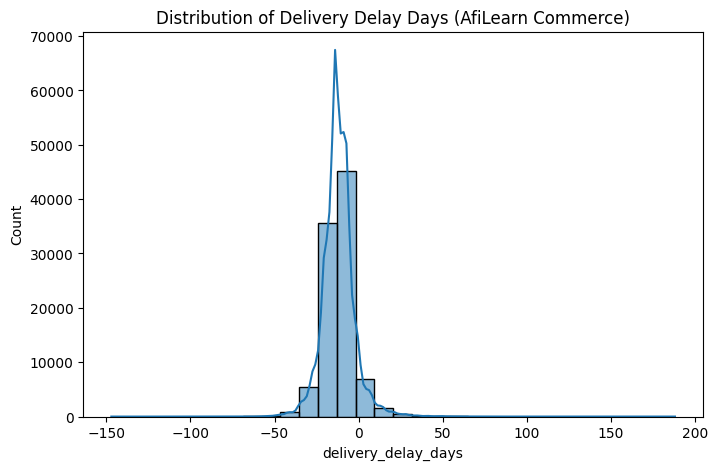

In [8]:
# 4. DISTRIBUTION CHART REQUIREMENT: Save basic exploratory chart to disk
plt.figure(figsize=(8, 5))
sns.histplot(data=df_orders, x='delivery_delay_days', bins=30, kde=True)
plt.title("Distribution of Delivery Delay Days (AfiLearn Commerce)")
plt.savefig("../dashboards/screenshots/delivery_delay_distribution.png")